In [1]:
!sshfs -o reconnect,ServerAliveInterval=120,ServerAliveCountMax=3 rennes.g5k:/srv/storage/empenn@storage2.rennes.grid5000.fr/private/ymerel /home/ymerel/storage


fusermount3: failed to access mountpoint /home/ymerel/storage: Permission denied


In [2]:
import os

case = 'case_study_2_revised'
projdir = "/home/ymerel/fmri/sosym_2026"
resdir = os.path.join(projdir, "results", case)
datadir = os.path.join(projdir, "data", case)
corr_func = 'spearman'
storagedir = "/home/ymerel/storage/results/"
jobname = "motor_sosym"
output_path = f"{storagedir}{jobname}"
ds_path = os.path.join(datadir, 'normalized_dataset.csv')
corr_path = os.path.join(datadir, 'correlations.csv')

# Load data

In [3]:
import numpy as np
import pandas as pd

dataset = pd.read_csv(ds_path, delimiter=';')

print(f"{len(dataset)} configs in dataset")

correlations = pd.read_csv(corr_path, delimiter=';')
print(f"{len(correlations)} correlations in matrix")

matrix = correlations.pivot(index='source', columns='target', values=corr_func).fillna(1.0)

dataset.head(1010)

1001 configs in dataset
1004004 correlations in matrix


,slice_timing_correction/ref_slice/middle,distorsion_correction,signal_modeling/temporal_noise_autocorrelation/FAST,slice_timing_correction,signal_modeling/temporal_noise_autocorrelation/AR1,spatial_normalization/algorithm/linear,motion_correction_realignment/register_to/mean,signal_modeling/hrf/temporal_derivs,spatial_normalization/algorithm/DARTEL,signal_modeling/hrf/canonical,...,spatial_normalization/bias_fwhm,spatial_smoothing/fwhm,spatial_normalization/interpolation/trilinear,spatial_normalization/template/MNI305,spatial_normalization/interpolation/bspline,id,pearson_from_ref,spearman_from_ref,pearson_from_mean,spearman_from_mean
0,False,False,True,False,False,False,True,True,False,False,...,0,6,False,False,False,d73e0359ec51c3b847656b8f2bc157b083dae2057d53a4...,0.160130,0.113577,0.285253,0.258097
1,False,False,True,True,False,False,False,False,False,True,...,0,6,True,False,False,e012bd4d9bab5a18593441c76f48ccc732bca3390703ff...,0.153044,0.103219,0.338549,0.287203
2,True,False,True,True,False,False,False,True,False,False,...,0,6,True,False,False,850e4d92a370900eede8982155772f1ba014ab468eef7c...,0.992108,0.962106,0.820359,0.649932
3,False,False,True,True,False,False,False,True,False,False,...,0,6,True,False,False,84c27a9d96a41f520b1de0bf3ef88093bcf9761b45e45e...,0.897479,0.775694,0.759085,0.578920
4,False,False,True,True,False,False,True,False,False,False,...,0,6,True,False,False,0c7beba1bec8f4ff1c5ebff7e2af248230c4ce91c27775...,0.417429,0.310260,0.656119,0.519583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,True,False,False,True,True,False,True,False,False,False,...,0,6,True,False,False,478226e8b91fd9e223848097af04e9841a0c7c8bebe003...,0.789798,0.637375,0.898010,0.732621
997,False,False,False,False,True,False,True,True,False,False,...,0,6,False,False,False,49b2e420e59aac429dbf460a5814461a2b645eb20f2387...,0.805810,0.660484,0.869937,0.695540
998,False,False,False,True,True,False,False,False,False,True,...,0,6,False,False,True,2a1e8f3ad608486da7eb9f165fa6389c641a895232a3dc...,0.735702,0.571877,0.933879,0.786111
999,True,False,True,True,False,False,True,False,False,True,...,0,6,False,False,False,cd5f0844e445d6ab574976706eb2929d22072940c7433e...,0.597593,0.465796,0.785186,0.623949


# Compute dendogram, medoids and anti-medoids

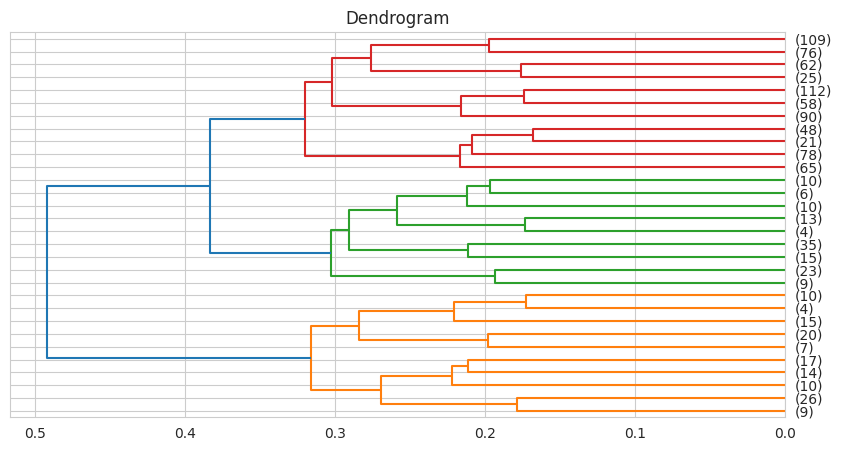

[20] clusters for t=0.2


In [4]:
from src.utils import clusterize_hierch, predict_clusters, get_cluster_distance_densities, get_cluster_cophenetic,get_cluster_silhouette, get_cluster_inertia, get_davies_bouldin, get_medoids, get_antimedoids
from src.plot_utils import plot_brain
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

all_results = []

threshold = 0.20

# cluster on whole dataset
ds, distance_matrix, Z, clusters = clusterize_hierch(dataset, correlations, dataset['id'], None, corr_func, threshold)

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', distance_sort=True, orientation='left')
plt.title('Dendrogram')
plt.show()

medoids = get_medoids(distance_matrix, clusters)
# sort by cluster label
medoids = {k: medoids[k] for k in sorted(medoids.keys())} 
antimedoids = get_antimedoids(distance_matrix, clusters)

print(f'[{len(medoids.items())}] clusters for t={threshold}')

# Plot clusters (medoids, antimedoids)

Cluster [1] - Correlation to ref [0.5689195416374216] - Medoid [9fb77bd6f125fc67c8b84914b11b480799eeb7ebd4acd785ddbe0feb54b6f604]


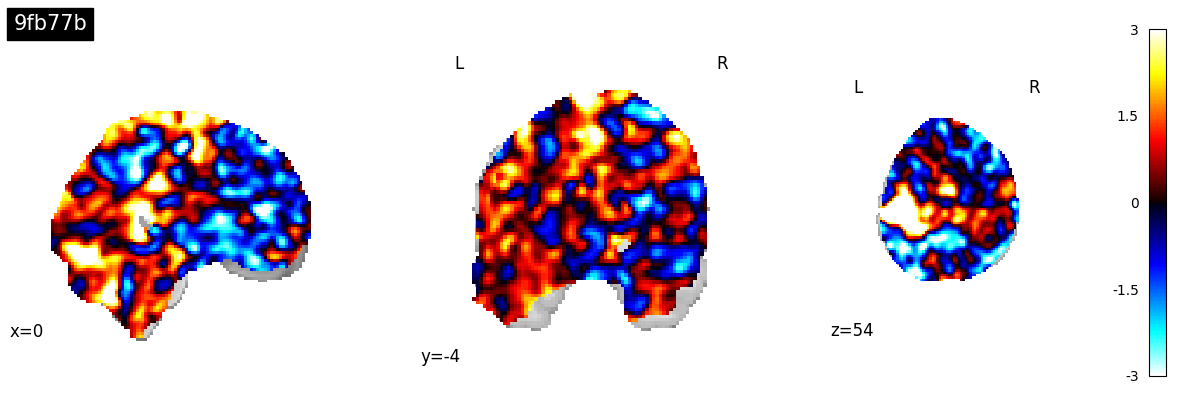

Cluster [1] - Antimedoid


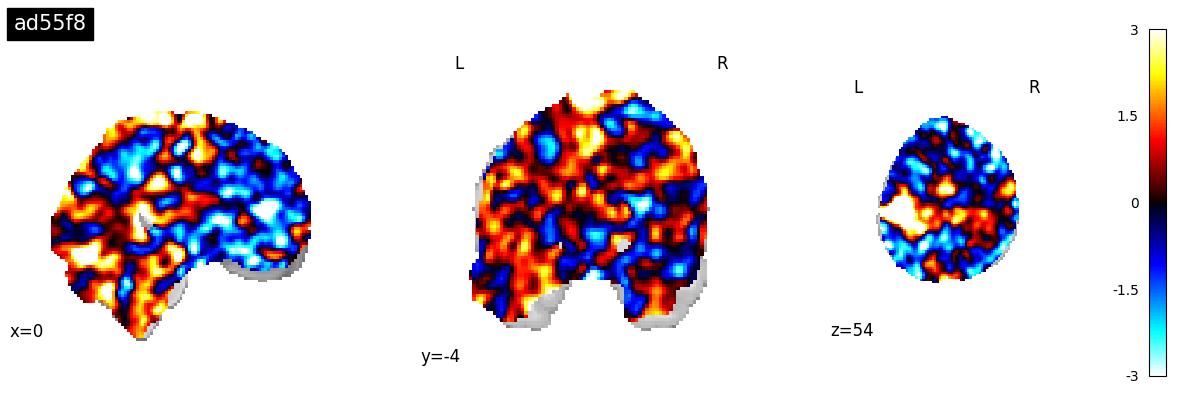

Cluster [2] - Correlation to ref [0.6332078642633486] - Medoid [1b721502bede617b46ef759f21ad17757809cd15537bb1da3131522b0ded4d02]


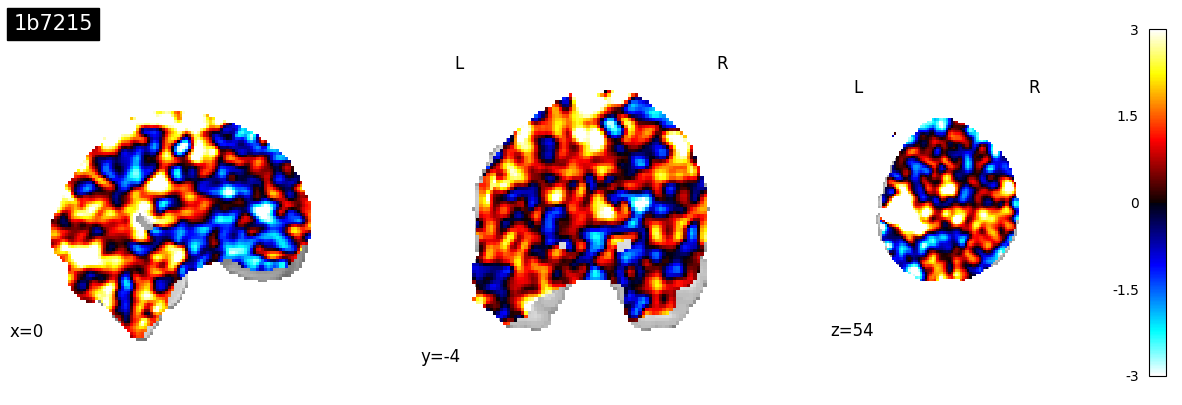

Cluster [2] - Antimedoid


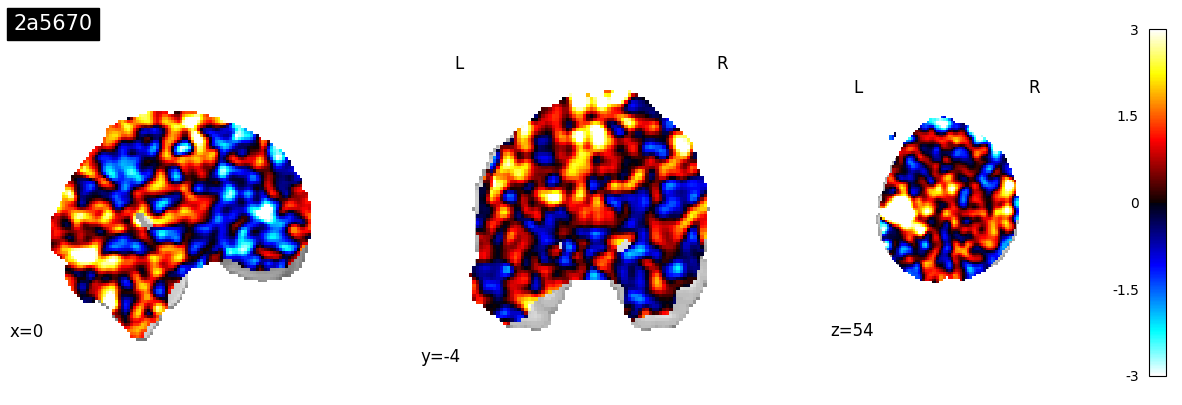

Cluster [3] - Correlation to ref [0.7869741992195025] - Medoid [2a3f25e2b92994170ea3ff9ab4896f20bb7276787cda27e3e589972a6301b073]


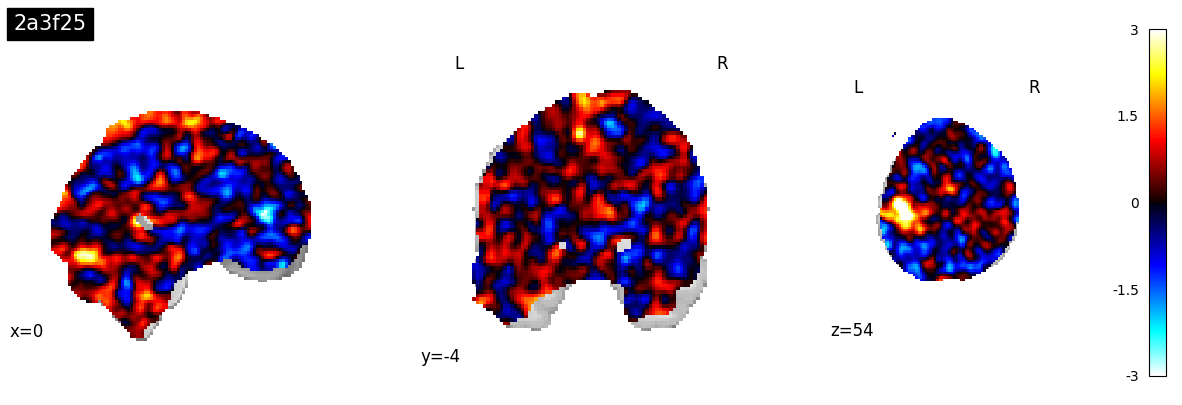

Cluster [3] - Antimedoid


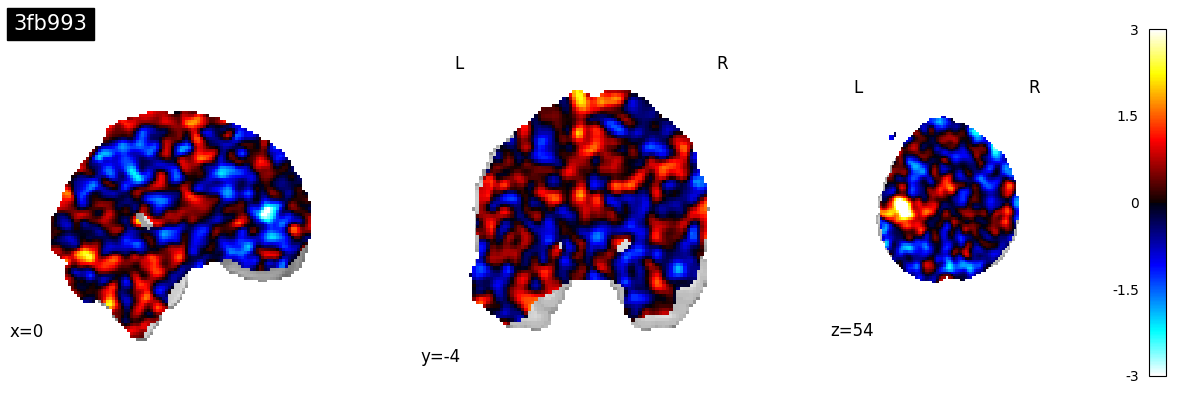

Cluster [4] - Correlation to ref [0.7638011449559702] - Medoid [952bc39b69fea69f88a040dc9c929280ef1a600a940f9ed01194a2c2309fb4ef]


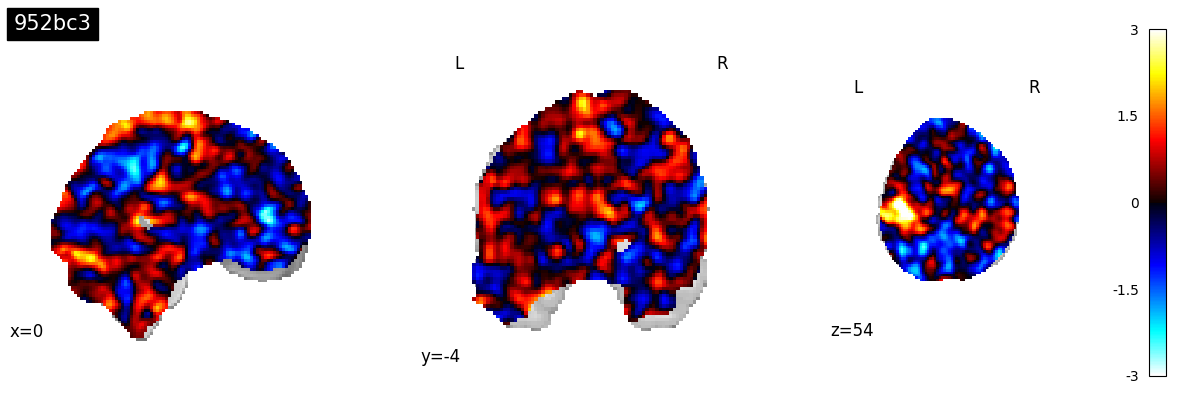

Cluster [4] - Antimedoid


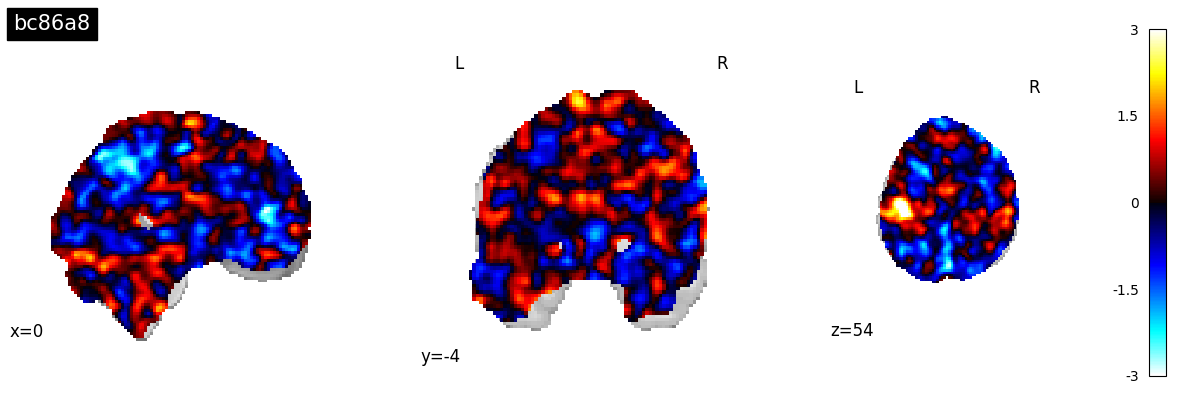

Cluster [5] - Correlation to ref [0.5907504665969898] - Medoid [e69abb3baa2d79ad5397987030abdee5052412a3221ee5d020de236746945c1b]


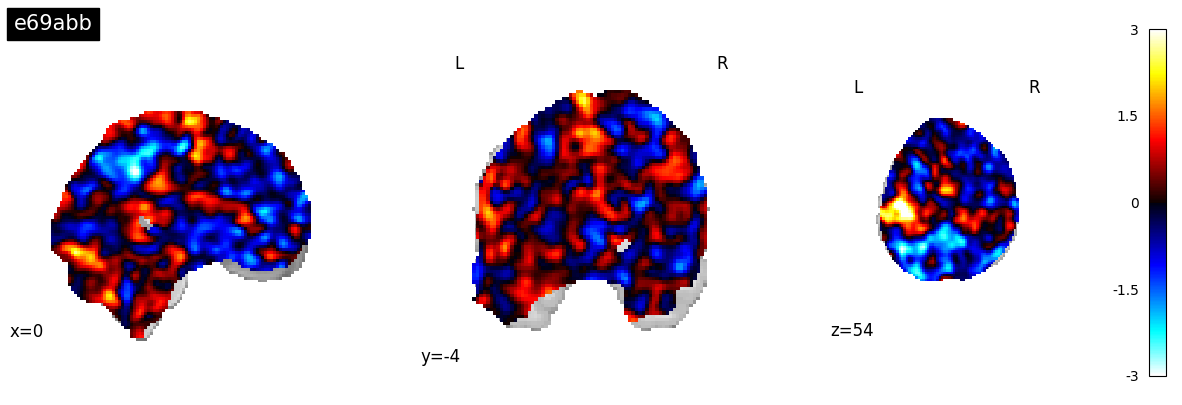

Cluster [5] - Antimedoid


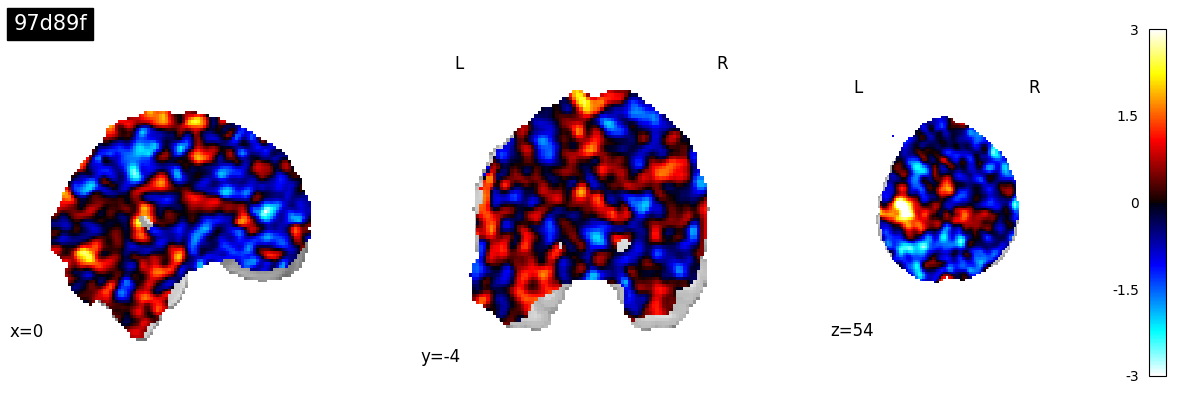

Cluster [6] - Correlation to ref [1.0] - Medoid [ref]


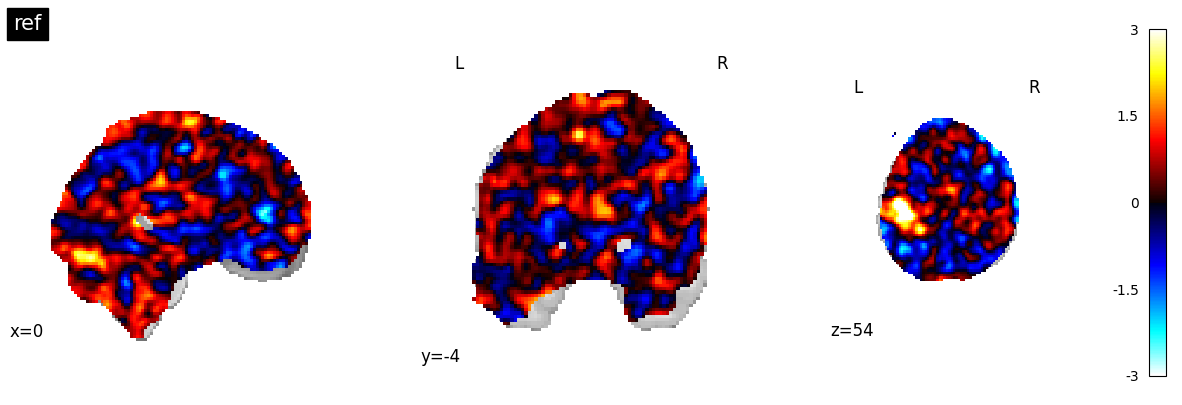

Cluster [6] - Antimedoid


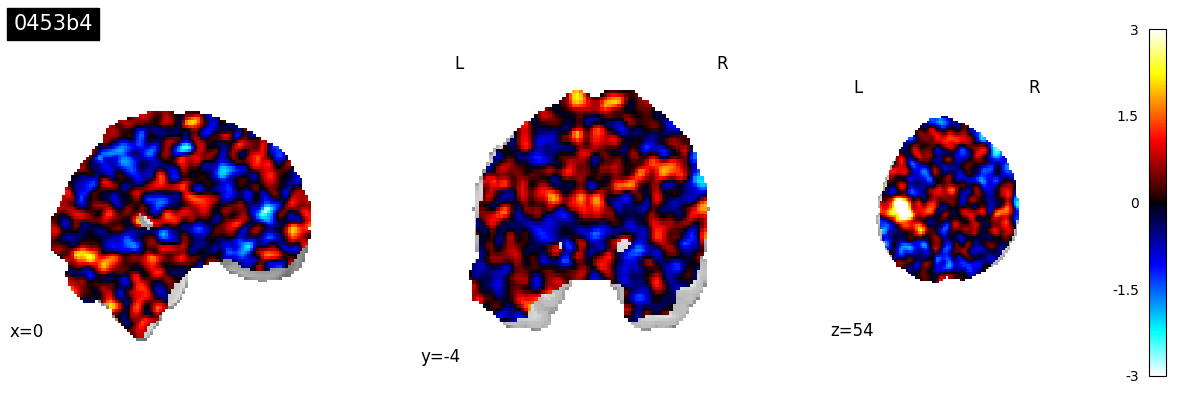

Cluster [7] - Correlation to ref [0.4101256011051554] - Medoid [170078f5ed57c05c110b634a311a33c8e888bff2df040886ea0b73aa4d09149b]


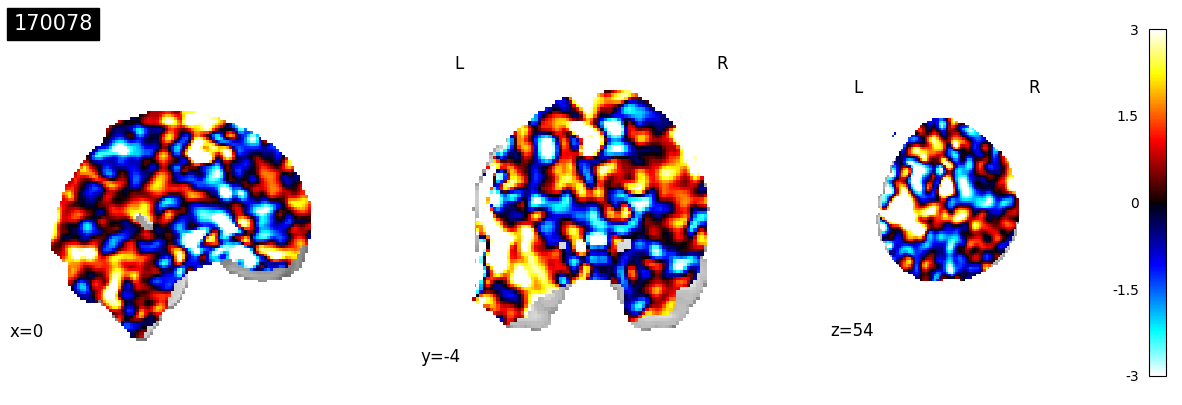

Cluster [7] - Antimedoid


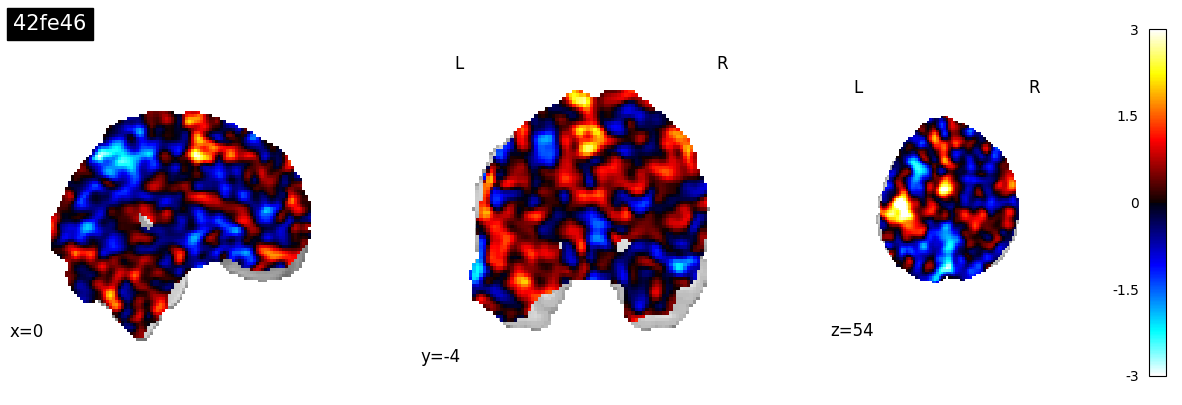

Cluster [8] - Correlation to ref [0.3703948114796108] - Medoid [63cca465dab428e4a061566b4ec70c5d536e2ee0f1665c312dc89b5a9e555b7b]


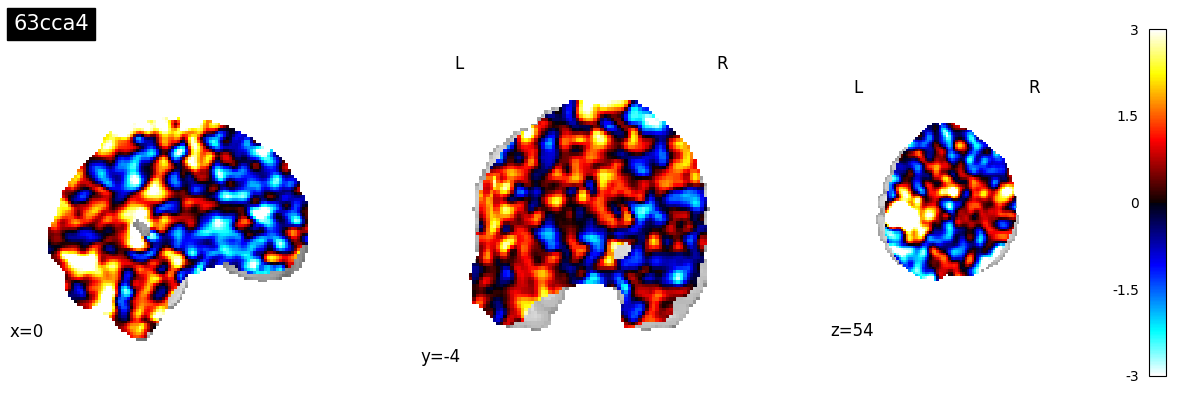

Cluster [8] - Antimedoid


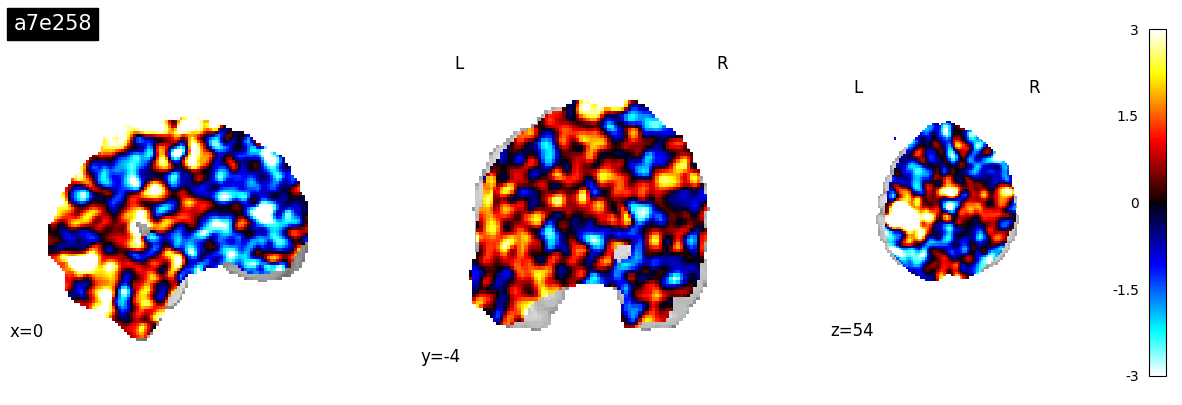

Cluster [9] - Correlation to ref [0.3766340885213083] - Medoid [37dd92ca7ddadf95a5a17a767eb40f0d37e2a28fdb6e0aa30f937eb168687346]


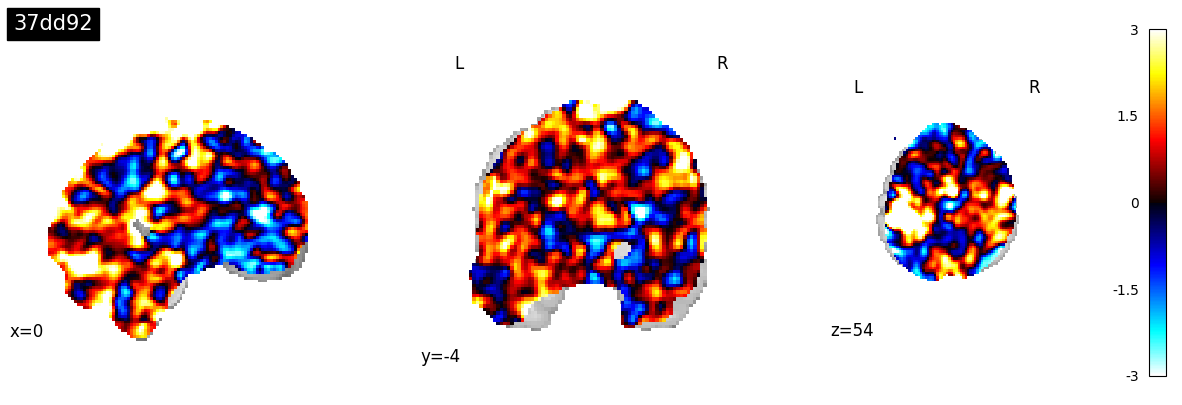

Cluster [9] - Antimedoid


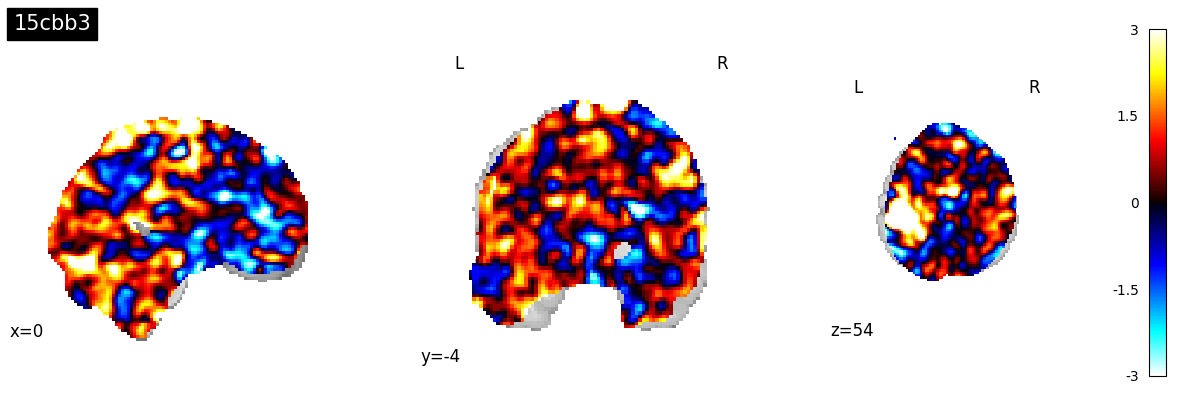

Cluster [10] - Correlation to ref [0.4138147085306921] - Medoid [8eb1d19565138d9270bc305048662534319058d810cb80cc1d0b97ed90dd4970]


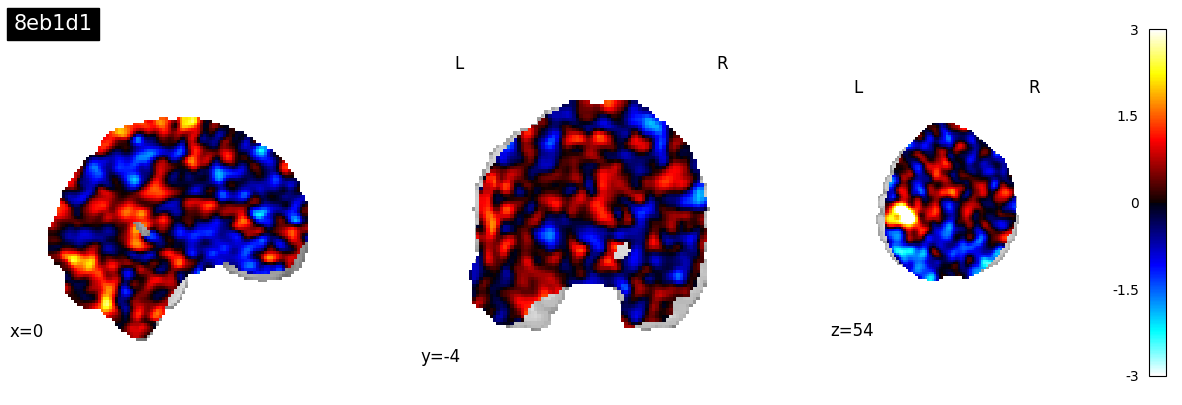

Cluster [10] - Antimedoid


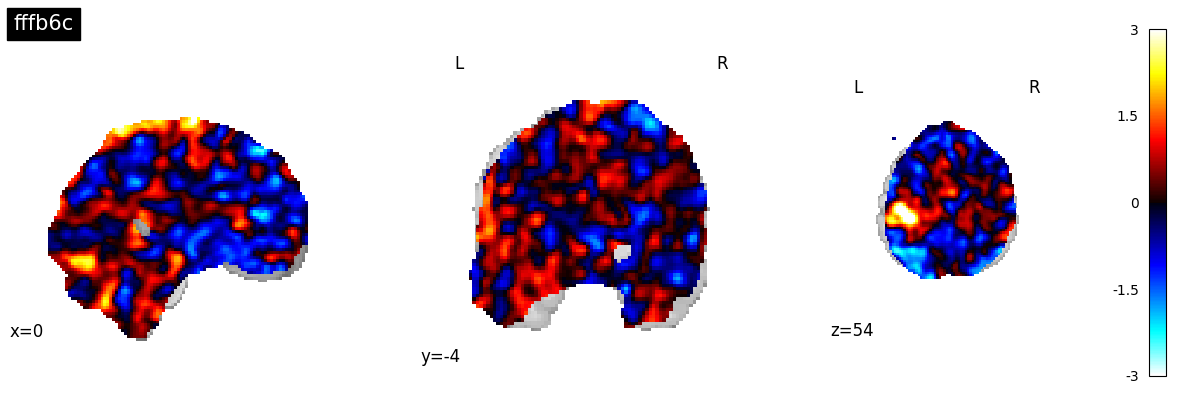

Cluster [11] - Correlation to ref [0.2865888766418971] - Medoid [e353e5d18c8af408634835180e849884ec30025a4f1b698bcb1e2e3703a35053]


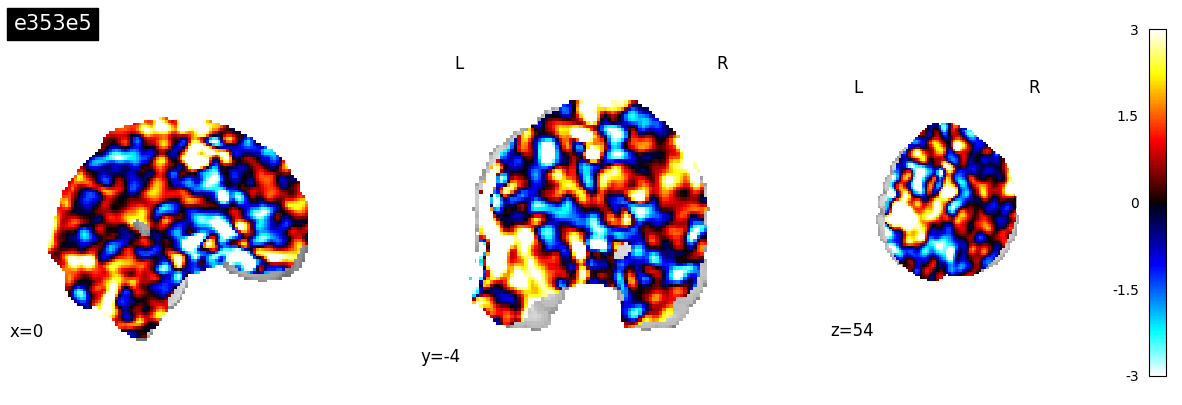

Cluster [11] - Antimedoid


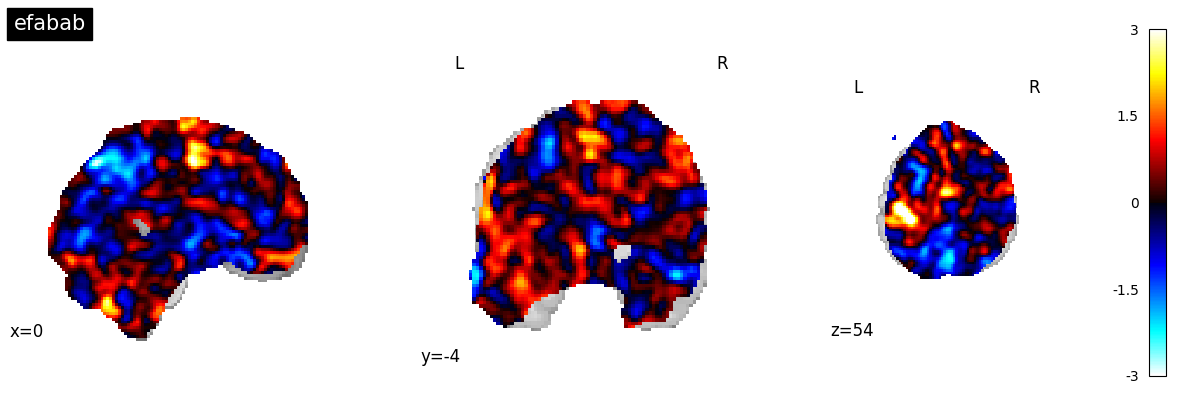

Cluster [12] - Correlation to ref [0.4009936810120902] - Medoid [ec3f027cfb2fb0658f001efc41553b2084b14db7d14659946df2323cae37dea0]


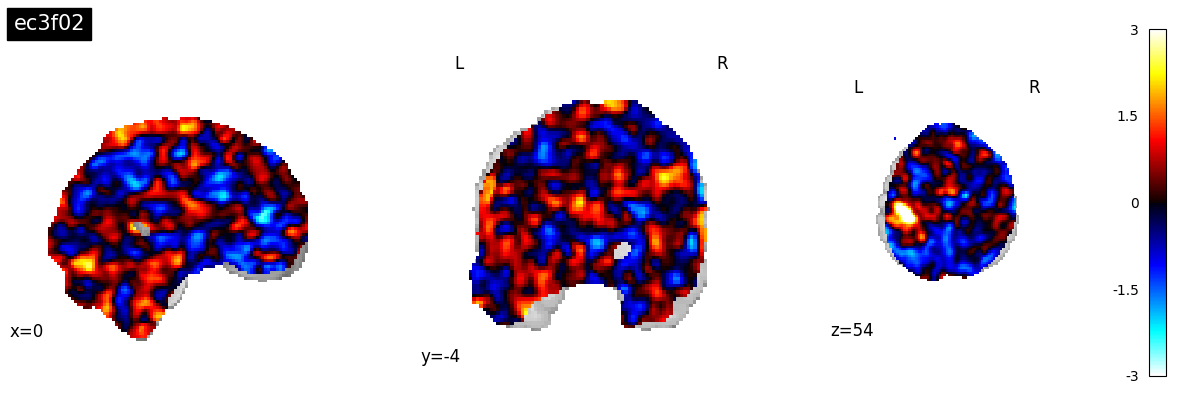

Cluster [12] - Antimedoid


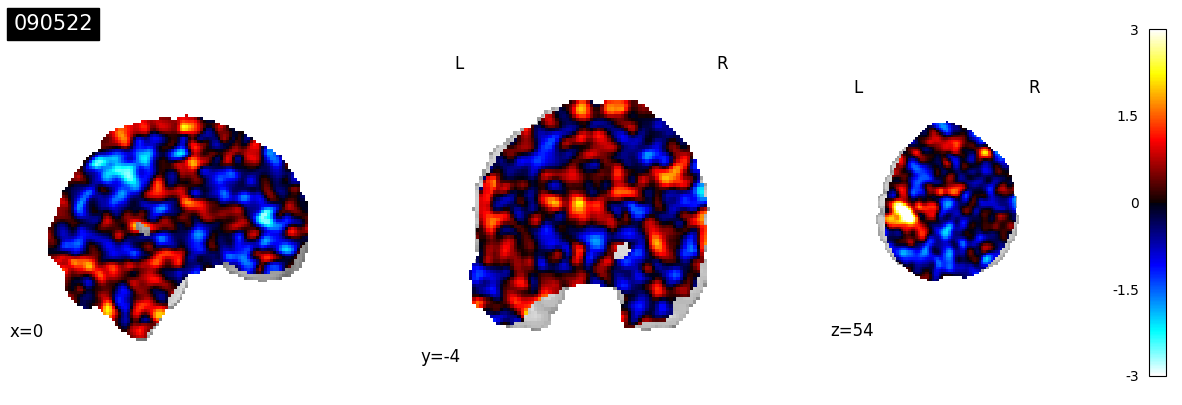

Cluster [13] - Correlation to ref [0.4891578960181761] - Medoid [bc5b2602dbb6d72fa9f3e806ead7dd6d3f68ce99b5888457c2404047c974cec3]


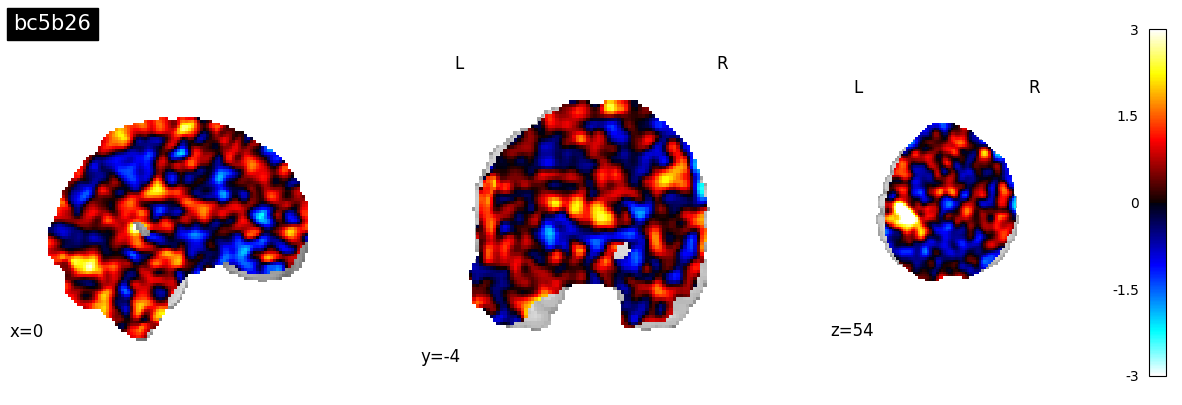

Cluster [13] - Antimedoid


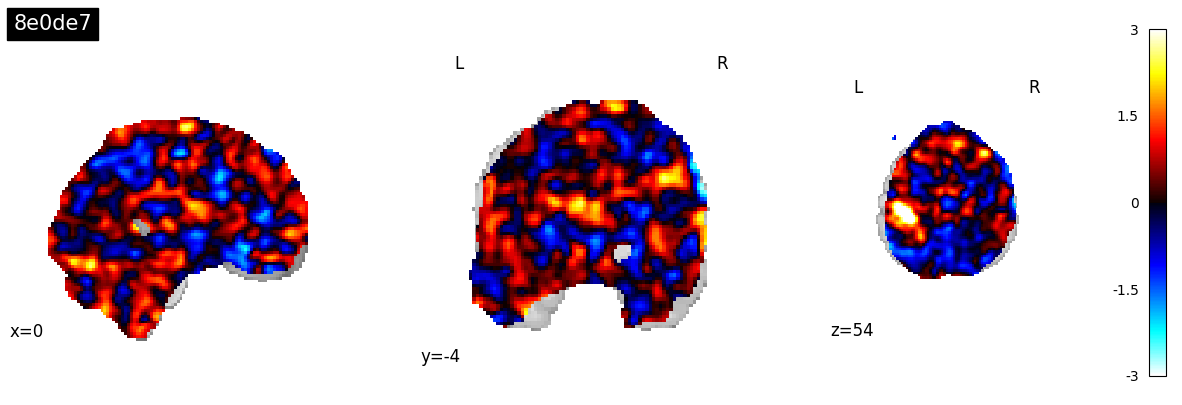

Cluster [14] - Correlation to ref [0.1314478431316596] - Medoid [33a472b81e57b67e5104dd97836ea543dd48fa43faa02c64628a7ade3fab573b]


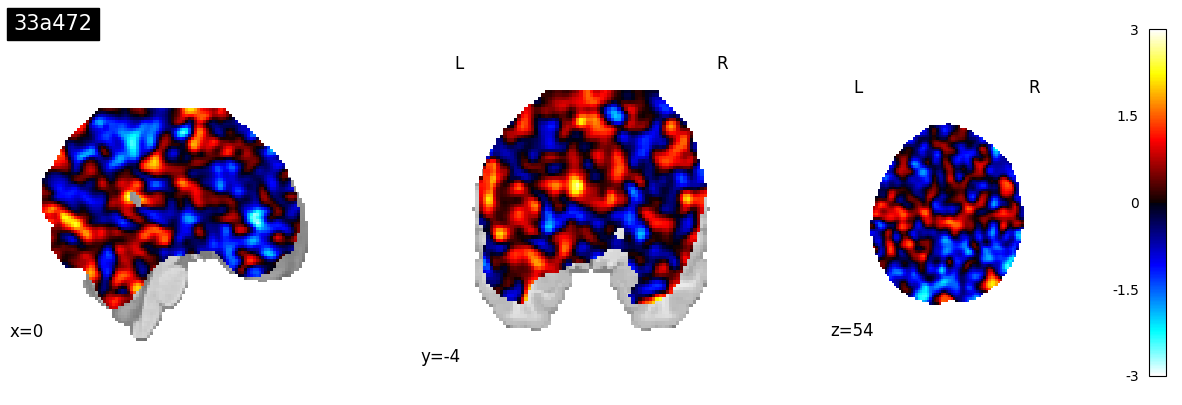

Cluster [14] - Antimedoid


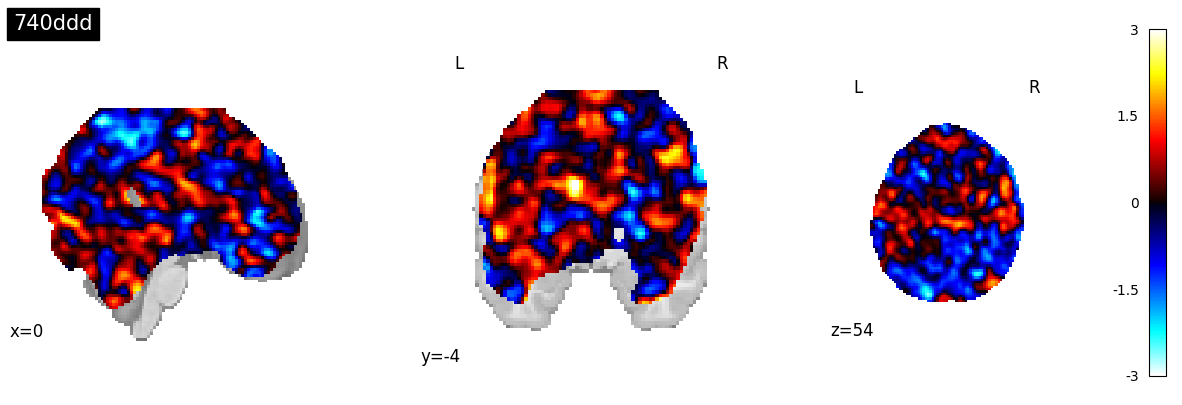

Cluster [15] - Correlation to ref [0.0828565820794563] - Medoid [acc932a4c66f03b1e2863c9f2c8d4d713a6dd6d228378cf28d26fda5df781bcb]


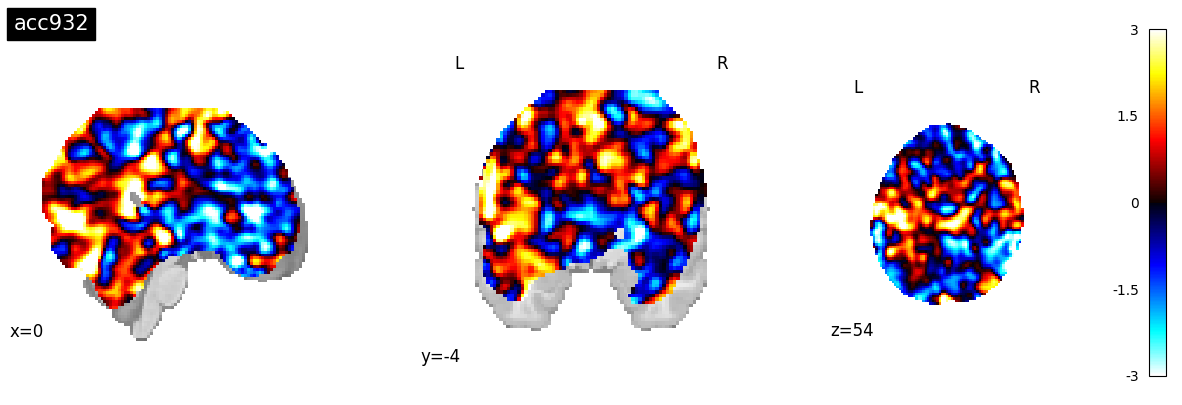

Cluster [15] - Antimedoid


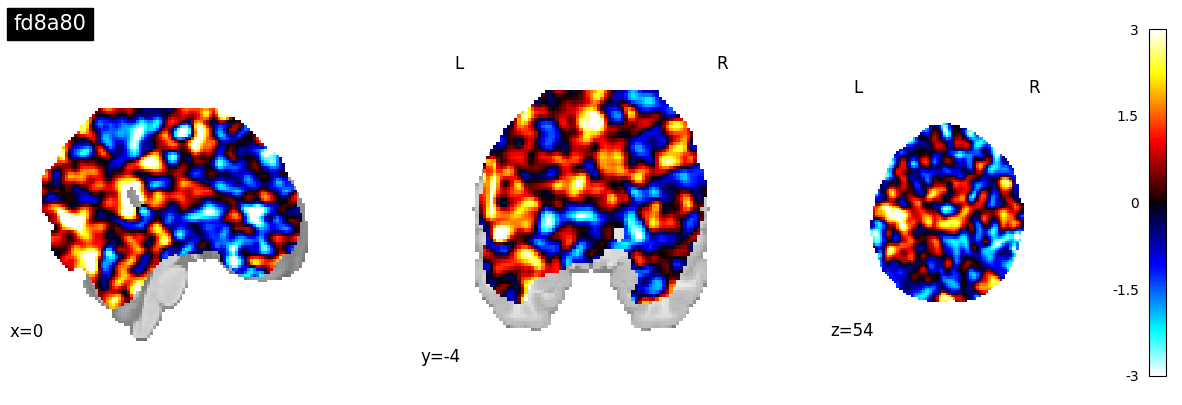

Cluster [16] - Correlation to ref [0.1132129370745807] - Medoid [94a701d56776deca4f53cde24ee78fd5cabf4711f03404016cccce0284c59cc2]


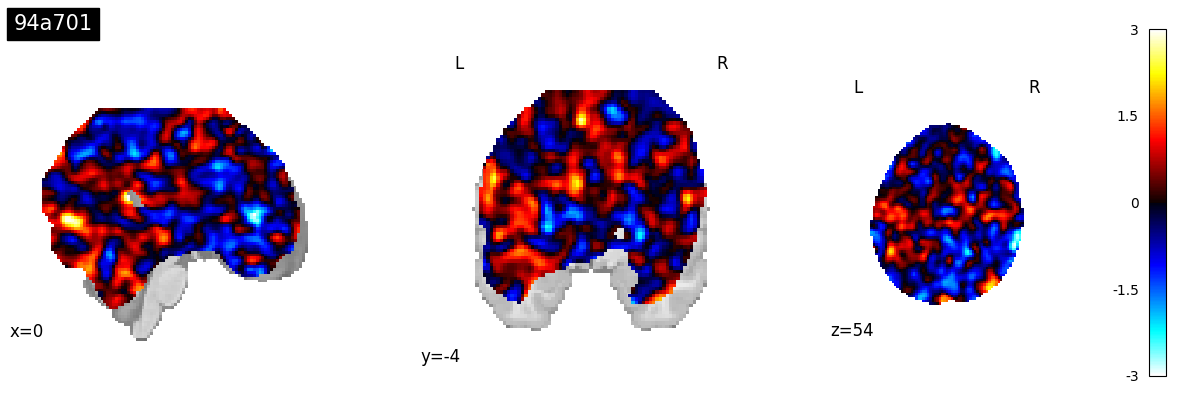

Cluster [16] - Antimedoid


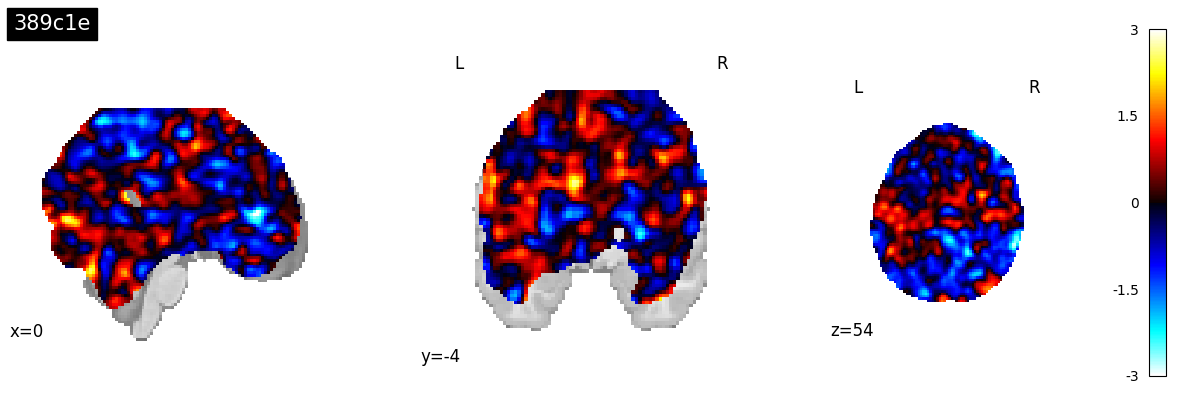

Cluster [17] - Correlation to ref [0.0963496830312574] - Medoid [4600c4fcc975d159a5e3ffbfcdd460a5f0b55113d1a74f9251f432d5c087b232]


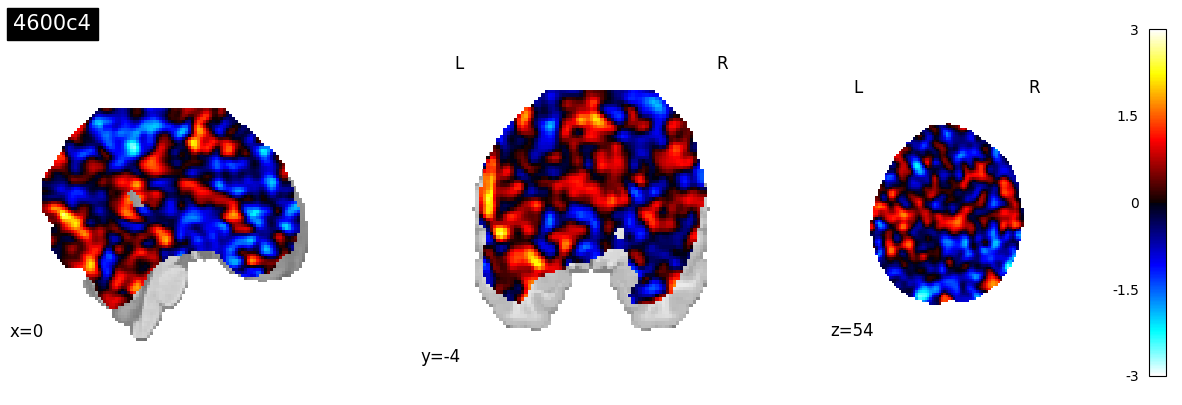

Cluster [17] - Antimedoid


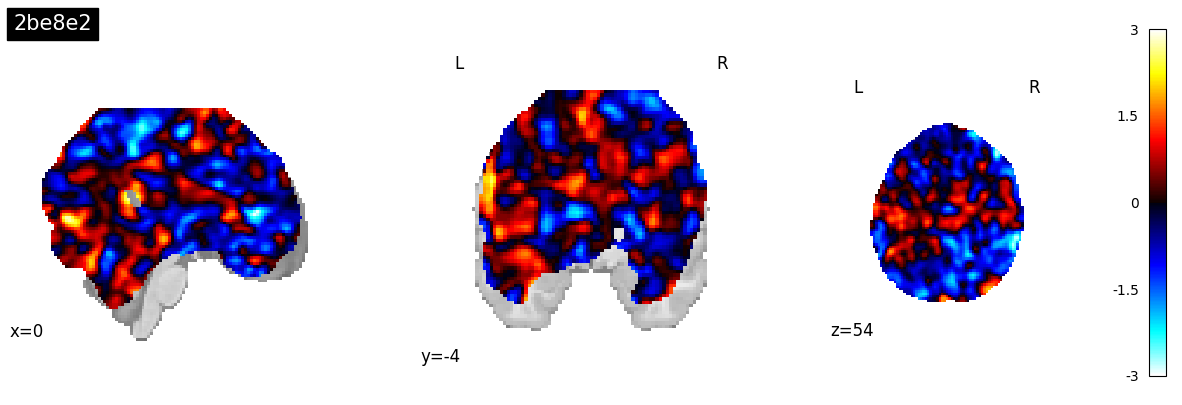

Cluster [18] - Correlation to ref [0.0952542894055297] - Medoid [a5cc50079a6a0390429ad8f2d371e6e9c87c1070244cdd70bbcb99d92412416b]


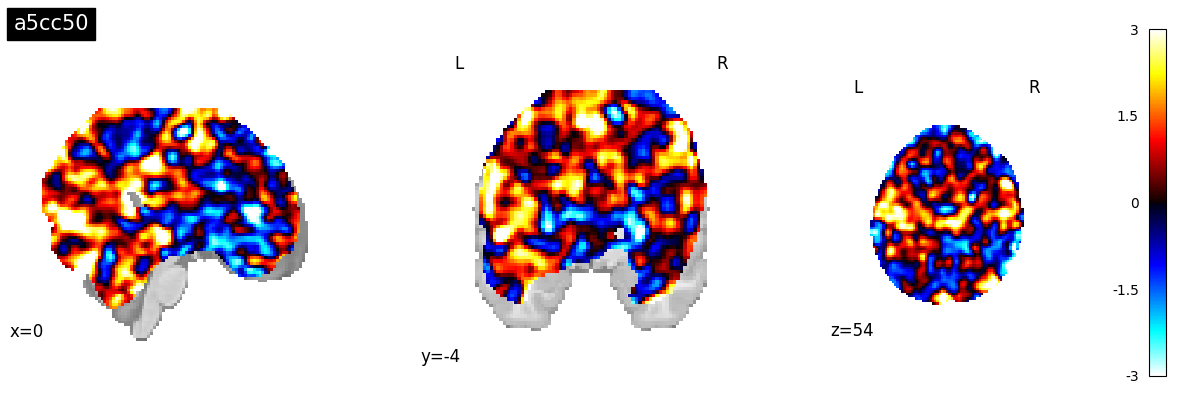

Cluster [18] - Antimedoid


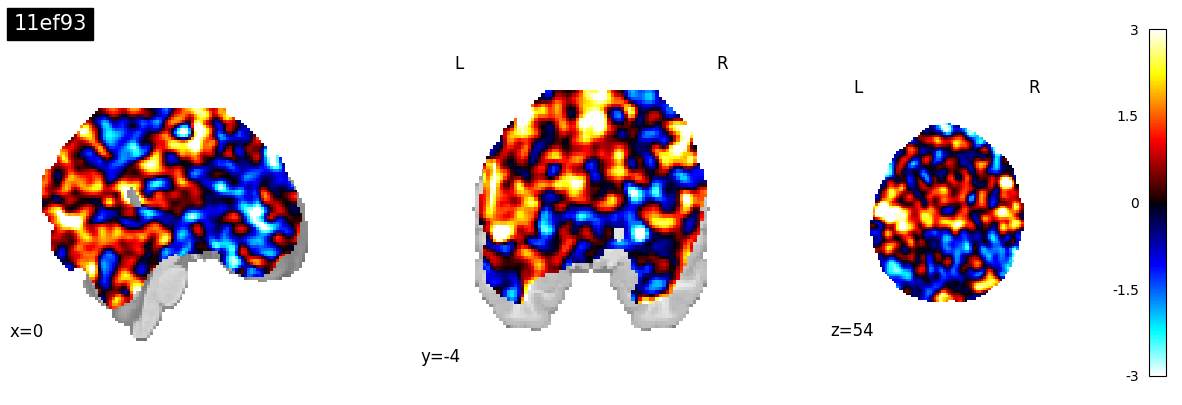

Cluster [19] - Correlation to ref [0.0630735049607837] - Medoid [742e44986a4dbd047758798d776a4127bd75b585b6f783209a1afc2d78c62468]


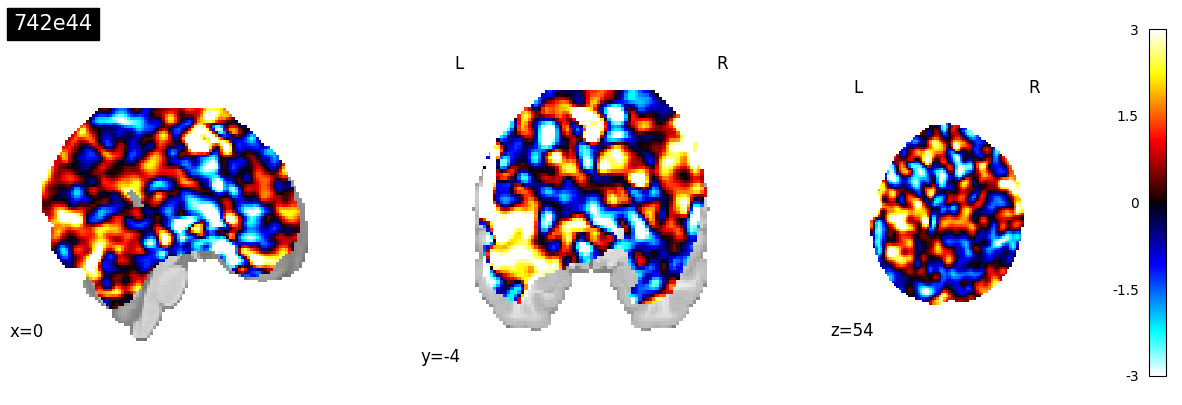

Cluster [19] - Antimedoid


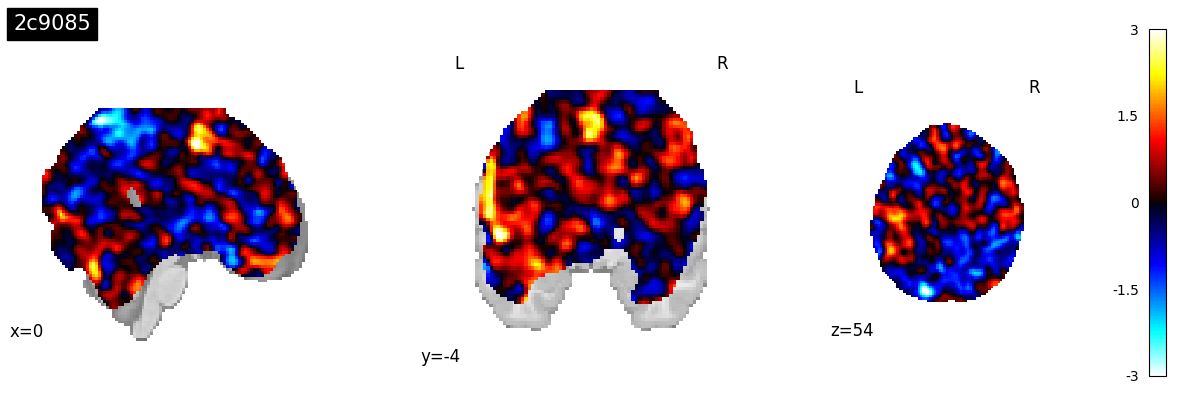

Cluster [20] - Correlation to ref [0.1250779103529491] - Medoid [291a8d89c3ed1cb890029c0567c39fc9aa0fe3724462c23a1be12f857a31cf5c]


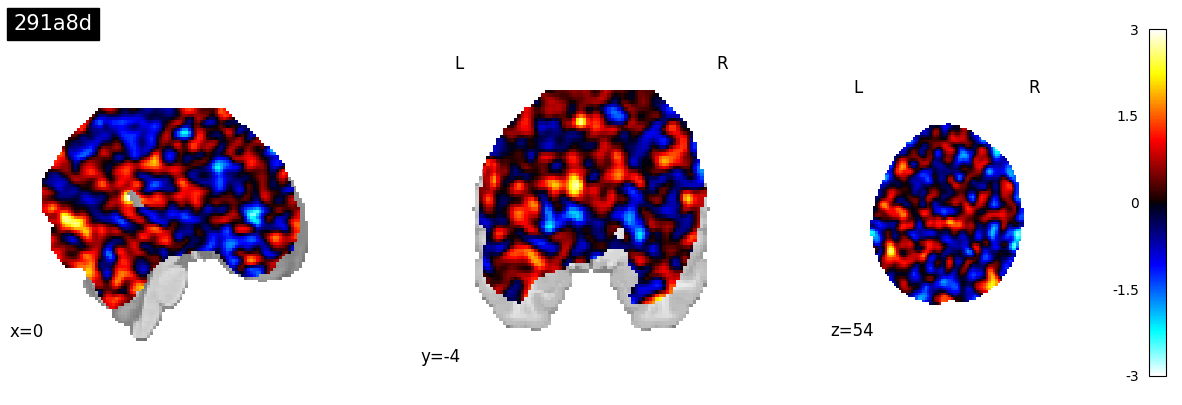

Cluster [20] - Antimedoid


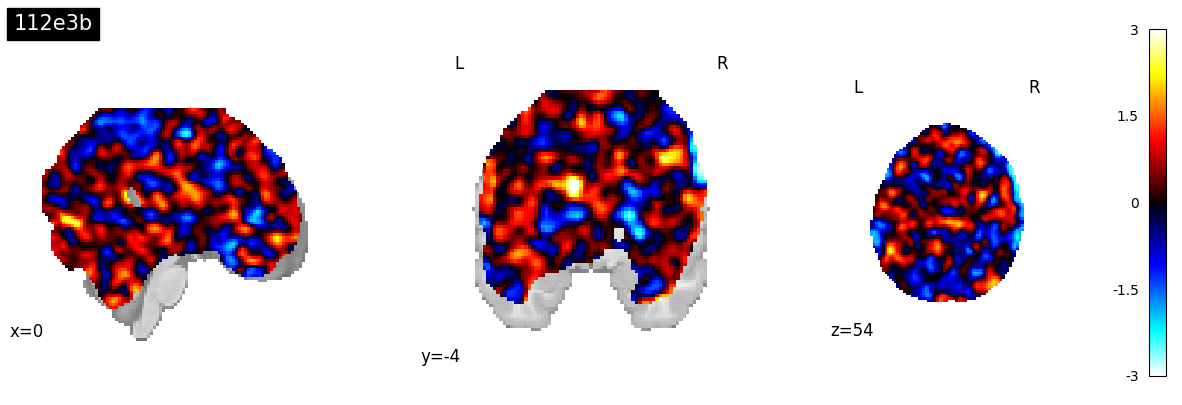

In [5]:
coords = [0, -4, 54]
for key, value in medoids.items():
    print(f"Cluster [{key}] - Correlation to ref [{dataset.loc[dataset['id'] == value, f'{corr_func}_from_ref'].values[0]}] - Medoid [{value}]")
    img_path = os.path.join(output_path, value, 'spmT_0001.nii')
    plot_brain(img_path, None, coords)
    print(f"Cluster [{key}] - Antimedoid")
    img_path = os.path.join(output_path, antimedoids[key], 'spmT_0001.nii')
    plot_brain(img_path, None, coords)

# Define Valid / Invalid clusters

In [6]:
all_clusters = clusters.unique().tolist()
# Pearson with t=0.2
# valid_clusters = [1, 2, 3, 4, 5, 6]
# invalid_clusters = [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
# Sperman with t=0.2
valid_clusters = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
invalid_clusters = [14, 15, 16, 17, 18, 19, 20]
print(f"Valid clusters: {len(valid_clusters)}/{len(all_clusters)}")
print(f"Invalid clusters: {len(invalid_clusters)}/{len(all_clusters)}")

Valid clusters: 13/20
Invalid clusters: 7/20


In [7]:
print(f"Excludes {len(invalid_clusters)} clusters")

valid_ds = ds[~ds['cluster'].isin(invalid_clusters)]
valid_ds.to_csv(os.path.join(datadir, f'valid_dataset.csv'), index=False, sep=';')
print(f"Valids : {len(valid_ds)} - Correlations from ref. : [{valid_ds[valid_ds['id'] != 'ref']['spearman_from_ref'].min()} - {valid_ds[valid_ds['id'] != 'ref']['spearman_from_ref'].max()}]")
print(f"Valids : {len(valid_ds)} - Correlations from mean : [{valid_ds[valid_ds['id'] != 'ref']['spearman_from_mean'].min()} - {valid_ds[valid_ds['id'] != 'ref']['spearman_from_mean'].max()}]")

invalid_ds = ds[ds['cluster'].isin(invalid_clusters)]
invalid_ds.to_csv(os.path.join(datadir, f'invalid_dataset.csv'), index=False,sep=';') 
print(f"Invalids : {len(invalid_ds)} - Correlations from ref. : [{invalid_ds['spearman_from_ref'].min()} - {invalid_ds['spearman_from_ref'].max()}]")
print(f"Invalids : {len(invalid_ds)} - Correlations from mean : [{invalid_ds[invalid_ds['id'] != 'ref']['spearman_from_mean'].min()} - {invalid_ds[invalid_ds['id'] != 'ref']['spearman_from_mean'].max()}]")

Excludes 7 clusters
Valids : 869 - Correlations from ref. : [0.2677021109590394 - 0.9983133613603812]
Valids : 869 - Correlations from mean : [0.4526599076543355 - 0.7888265282565129]
Invalids : 132 - Correlations from ref. : [0.059658784759273 - 0.1356087914711643]
Invalids : 132 - Correlations from mean : [0.2531448659688683 - 0.3280506273439341]


# Plot clusters by distance from reference / mean result

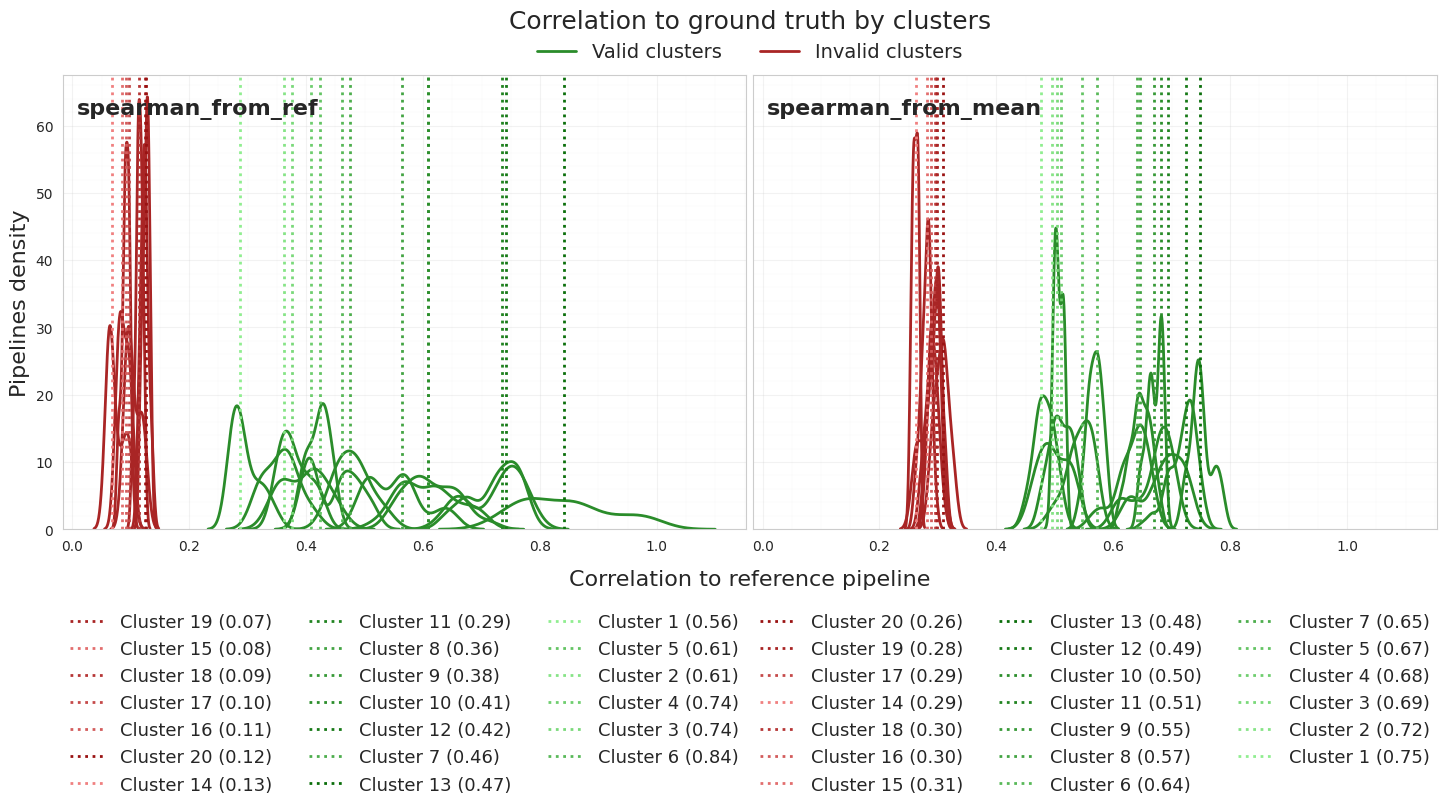

In [8]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from matplotlib.colors import LinearSegmentedColormap
import os

# Define the tasks and their respective directories
truths = [f'{corr_func}_from_ref', f'{corr_func}_from_mean']

# Create a figure with two subplots side by side, increased width and height
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True, sharex=True)
fig.suptitle('Correlation to ground truth by clusters', fontsize=18, y=0.85)

# Define colormaps for green and red shades
green_cmap = LinearSegmentedColormap.from_list('green_shades', ['lightgreen', 'darkgreen'], N=100)
red_cmap = LinearSegmentedColormap.from_list('red_shades', ['lightcoral', 'darkred'], N=100)

plt.rcParams.update({'font.size': 14})

# Use the same shades for the legend as in the plots
valid_shade = green_cmap(0.7)
invalid_shade = red_cmap(0.7)

# Create a single legend for Valid/Invalid (no cluster count)
legend_handles = [
    plt.Line2D([0], [0], color=valid_shade, lw=2, label='Valid clusters'),
    plt.Line2D([0], [0], color=invalid_shade, lw=2, label='Invalid clusters')
]
fig.legend(handles=legend_handles, loc='upper center',
           ncol=2, frameon=False, fontsize=14,
           bbox_to_anchor=(0.5, 0.83))

i = 0
for truth in truths:
    datasets = {
        'Valid': pd.read_csv(os.path.join(datadir, 'valid_dataset.csv'), delimiter=';'),
        'Invalid': pd.read_csv(os.path.join(datadir, 'invalid_dataset.csv'), delimiter=';')
    }

    # Dictionary to store stats and medoids
    stats = {}
    medoids = {}

    # Calculate stats and find medoids for each dataset
    for label, df in datasets.items():
        stats[label] = {'mean': df[truth].mean()}
        cluster_medoids = {}
        for cluster in sorted(df['cluster'].unique()):
            cluster_data = df[df['cluster'] == cluster][truth].values.reshape(-1, 1)
            distances = cdist(cluster_data, cluster_data)
            medoid_idx = np.argmin(distances.sum(axis=1))
            cluster_medoids[int(cluster)] = cluster_data[medoid_idx][0]
        medoids[label] = cluster_medoids

    # Custom legend handles for medoids (to be placed under each subplot)
    medoid_legend_handles = []

    # Plot Invalid and Valid for the current truth
    for label in ['Invalid', 'Valid']:
        df = datasets[label]
        cmap = green_cmap if label == 'Valid' else red_cmap

        cluster_color = valid_shade if label == 'Valid' else invalid_shade

        for cluster in sorted(df['cluster'].unique()):
            cluster_data = df[df['cluster'] == cluster]
            sb.kdeplot(
                cluster_data[truth],
                color=cluster_color,
                linewidth=2,
                ax=axes[i]
            )

        # Plot medoids for each cluster (colored to match cluster)
        sorted_medoids = sorted(medoids[label].items(), key=lambda x: x[1])
        for j, (cluster, medoid) in enumerate(sorted_medoids):
            medoid_color = cmap(j / len(sorted_medoids))  # Distinct shade for medoids
            axes[i].axvline(medoid, color=medoid_color, linestyle=':', linewidth=2)

        # Add medoid entries to the legend handles
        for cluster, medoid in sorted_medoids:
            medoid_color = cmap(list(medoids[label].keys()).index(cluster) / len(medoids[label]))
            medoid_legend_handles.append(plt.Line2D([0], [0],
                color=medoid_color,
                linestyle=':', lw=2, label=f'Cluster {cluster} ({medoid:.2f})'))

    # Add task name in the top left or top right of each subplot
    axes[i].text(0.02, 0.95, f'{truth}',
                     transform=axes[i].transAxes,
                     fontsize=16, fontweight='bold',
                     verticalalignment='top')

    axes[i].grid(True)

    # Add medoids legend under each subplot
    if len(medoid_legend_handles) == 4:
        cols = 2
    else:
        cols = 3

    axes[i].legend(handles=medoid_legend_handles, loc='upper center',
                   bbox_to_anchor=(0.5, -0.15), ncol=cols, frameon=False, fontsize=13)
    i += 1

# Set y-label only for the left subplot
axes[0].set_ylabel('Pipelines density', fontsize=16)

# Remove x-axis labels for both subplots
for ax in axes:
    ax.set_xlabel('')

    # Major grid
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.25)

    # Minor ticks and grid
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)

    ax.set_axisbelow(True)  # Ensure grid is below data

# Add a single x-axis label centered below both subplots
fig.text(0.5, 0.13, 'Correlation to reference pipeline', ha='center', fontsize=16)

# Adjust layout to maximize plot width and prevent legend clipping
plt.tight_layout(rect=[0.02, 0.05, 0.98, 0.85])
plt.subplots_adjust(wspace=0.01, bottom=0.2)
plt.savefig("corr_to_ref.svg")
plt.show()


Valid from_ref
{'min': np.float64(0.2677021109590394), 'max': np.float64(1.0), 'mean': np.float64(0.5730641444543852)}
Invalid from_ref
{'min': np.float64(0.059658784759273), 'max': np.float64(0.1356087914711643), 'mean': np.float64(0.098121006072368)}


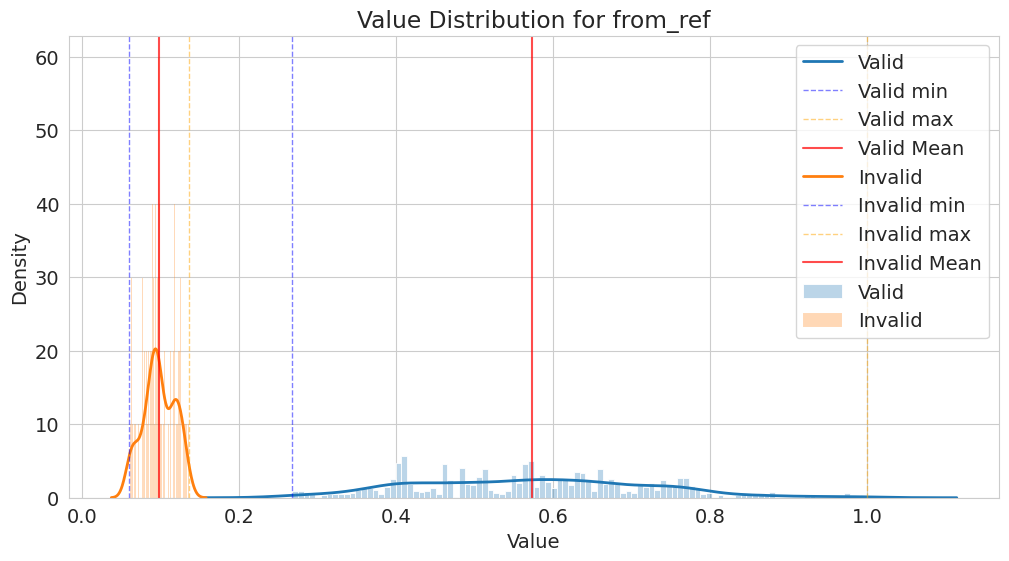

In [9]:
import seaborn as sb
# Create a dictionary to loop over the datasets
datasets = {
    'Valid': valid_ds,
    'Invalid': invalid_ds
}

# Calculate min, max, and mean for each dataset
stats = {}
for label, df in datasets.items():
    print(f"{label} from_ref")
    stats[label] = {
        'min': df[f'{corr_func}_from_ref'].min(),
        'max': df[f'{corr_func}_from_ref'].max(),
        'mean': df[f'{corr_func}_from_ref'].mean()
    }
    print(stats[label])

# Plot
plt.figure(figsize=(12, 6))
for label, df in datasets.items():
    sb.histplot(
        df[f'{corr_func}_from_ref'],
        bins=100,
        alpha=0.3,
        label=label,
        kde=False,
        stat='density'
    )
    sb.kdeplot(
        df[f'{corr_func}_from_ref'],
        label=label,
        linewidth=2
    )
    # Add vertical lines for min, max, and mean
    plt.axvline(stats[label]['min'], color='blue', linestyle='--', alpha=0.5, linewidth=1, label=f'{label} min')
    plt.axvline(stats[label]['max'], color='orange', linestyle='--', alpha=0.5, linewidth=1, label=f'{label} max')
    plt.axvline(stats[label]['mean'], color='red', linestyle='-', alpha=0.7, linewidth=1.5, label=f'{label} Mean')

plt.title('Value Distribution for from_ref')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

Valid from_mean
{'min': np.float64(0.4526599076543355), 'max': np.float64(0.7888265282565129), 'mean': np.float64(0.6598413153045788)}
Invalid from_mean
{'min': np.float64(0.2531448659688683), 'max': np.float64(0.3280506273439341), 'mean': np.float64(0.2895046213818637)}


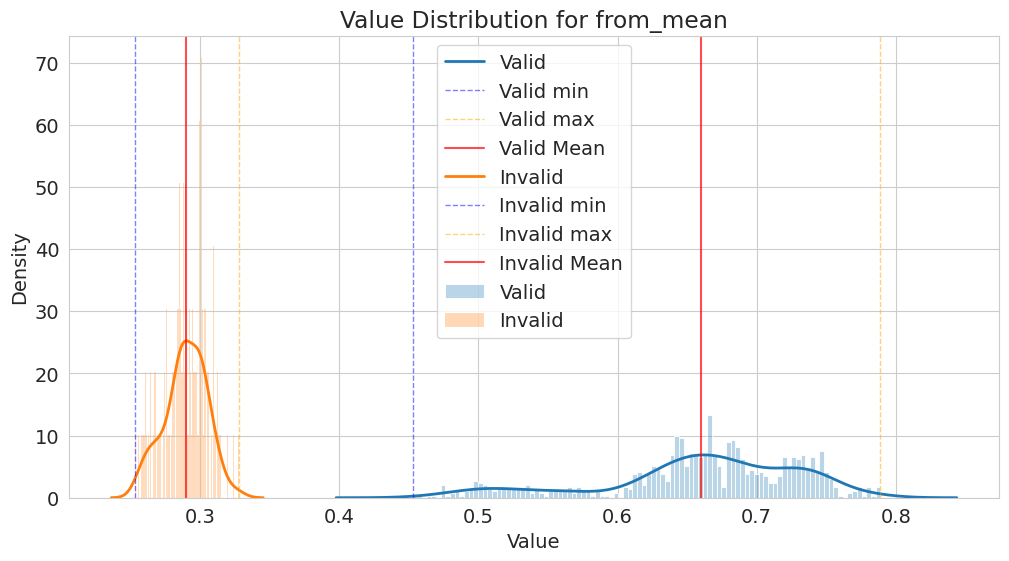

In [10]:
import seaborn as sb
# Create a dictionary to loop over the datasets
datasets = {
    'Valid': valid_ds,
    'Invalid': invalid_ds
}

# Calculate min, max, and mean for each dataset
stats = {}
for label, df in datasets.items():
    stats[label] = {
        'min': df[f'{corr_func}_from_mean'].min(),
        'max': df[f'{corr_func}_from_mean'].max(),
        'mean': df[f'{corr_func}_from_mean'].mean()
    }
    print(f"{label} from_mean")
    print(stats[label])

# Plot
plt.figure(figsize=(12, 6))
for label, df in datasets.items():
    sb.histplot(
        df[f'{corr_func}_from_mean'],
        bins=100,
        alpha=0.3,
        label=label,
        kde=False,
        stat='density'
    )
    sb.kdeplot(
        df[f'{corr_func}_from_mean'],
        label=label,
        linewidth=2
    )
    # Add vertical lines for min, max, and mean
    plt.axvline(stats[label]['min'], color='blue', linestyle='--', alpha=0.5, linewidth=1, label=f'{label} min')
    plt.axvline(stats[label]['max'], color='orange', linestyle='--', alpha=0.5, linewidth=1, label=f'{label} max')
    plt.axvline(stats[label]['mean'], color='red', linestyle='-', alpha=0.7, linewidth=1.5, label=f'{label} Mean')

plt.title('Value Distribution for from_mean')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
len_valid = len(valid_ds)
len_invalid = len(invalid_ds)
count = len(valid_ds[(valid_ds['coregistration/cost_function/normalised_cross_correlation'] == True) & (valid_ds['coregistration/source_target/anat_on_func'] == True)])
print(f"[{count}/{len_valid}] rows in [VALID] where [NCC = True AND anat_on_func = True]")
count = len(invalid_ds[(invalid_ds['coregistration/cost_function/normalised_cross_correlation'] == True) & (invalid_ds['coregistration/source_target/anat_on_func'] == True)])
print(f"[{count}/{len_invalid}] rows in [INVALID] where [NCC = True AND anat_on_func = True]")

[0/869] rows in [VALID] where [NCC = True AND anat_on_func = True]
[132/132] rows in [INVALID] where [NCC = True AND anat_on_func = True]


slice_timing_correction/ref_slice/middle                         0.336018
distorsion_correction                                            0.000000
signal_modeling/temporal_noise_autocorrelation/FAST              0.532796
slice_timing_correction                                          0.654776
signal_modeling/temporal_noise_autocorrelation/AR1               0.467204
spatial_normalization/algorithm/linear                           0.000000
motion_correction_realignment/register_to/mean                   0.515535
signal_modeling/hrf/temporal_derivs                              0.346375
spatial_normalization/algorithm/DARTEL                           0.000000
signal_modeling/hrf/canonical                                    0.338320
signal_modeling/nuisance_regressors                              0.750288
spatial_normalization/bias_regularisation/extremely_light        0.000000
motion_correction_realignment/register_to/first                  0.484465
spatial_normalization/bias_regularisat

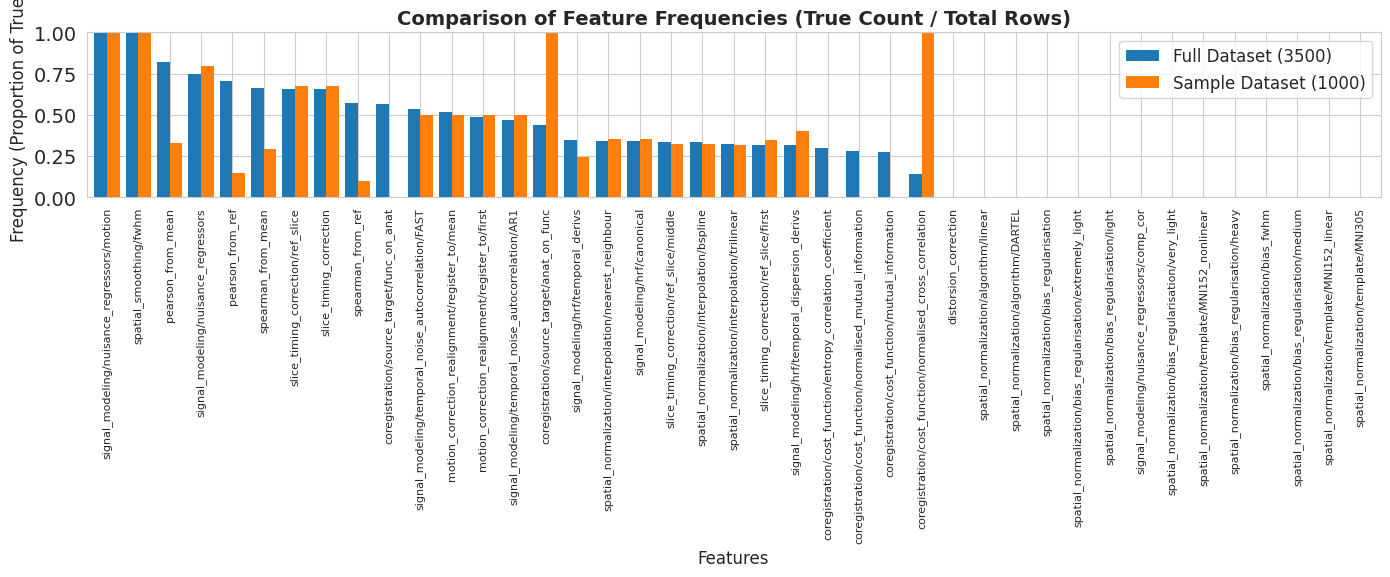

Total Variation Distance (TVD): 3.3862
signal_modeling/nuisance_regressors/motion                      1.582278
coregistration/cost_function/normalised_cross_correlation       0.856157
coregistration/source_target/anat_on_func                       0.562716
coregistration/source_target/func_on_anat                       0.562716
pearson_from_ref                                                0.559036
pearson_from_mean                                               0.490752
spearman_from_ref                                               0.474943
spearman_from_mean                                              0.370337
coregistration/cost_function/entropy_correlation_coefficient    0.301496
coregistration/cost_function/normalised_mutual_information      0.280783
dtype: float64
Mean Absolute Error (MAE): 0.1652


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

valid_ds = valid_ds.drop(['cluster', 'id'], axis=1)
invalid_ds = invalid_ds.drop(['cluster', 'id'], axis=1)

# --- Compute Frequencies (Proportion of True over Total Rows) ---
freq_full = valid_ds.mean()  # .mean() on booleans calculates the ratio of True
print(freq_full)
freq_sample = invalid_ds.mean()
# print(freq_sample)

# Combine into a single DataFrame for easy plotting
plot_df = pd.DataFrame(
    {"Full Dataset (3500)": freq_full, "Sample Dataset (1000)": freq_sample}
)

# Optional: Sort by the full dataset frequencies in descending order for clarity
plot_df = plot_df.sort_values(by="Full Dataset (3500)", ascending=False)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 6))

plot_df.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=["#1f77b4", "#ff7f0e"],
    edgecolor="none",
)

plt.title(
    "Comparison of Feature Frequencies (True Count / Total Rows)",
    fontsize=14,
    weight="bold",
)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Frequency (Proportion of True)", fontsize=12)
plt.ylim(0, 1.0)  # Frequencies range from 0 to 1
plt.xticks(rotation=90, fontsize=8)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

tvd = (freq_full - freq_sample).abs().sum() / 2
print(f"Total Variation Distance (TVD): {tvd:.4f}")
# See which features have the biggest individual discrepancies
diff = (freq_full - freq_sample).abs()
print(diff.sort_values(ascending=False).head(10))

# --- Compute Mean Absolute Error (MAE) ---
# This calculates the average absolute difference per feature
mae = (freq_full - freq_sample).abs().mean()

print(f"Mean Absolute Error (MAE): {mae:.4f}")